**Logistics Operations**

This notebook is created to analyze fleet maintenance downtime vs. vehicle age, tracking cost-per-mile, and modeling driver retention.

**Data Loading and Preprocessing**

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Kaggle API & Download Dataset
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d yogape/logistics-operations-database
!unzip -q logistics-operations-database.zip -d logistics_data

# 2. Create In-Memory SQLite Database & Load CSVs
conn = sqlite3.connect(':memory:')
tables = ['trucks', 'maintenance_records', 'fuel_purchases', 'drivers', 'trips', 'loads', 'truck_utilization_metrics']

for t in tables:
    df = pd.read_csv(f'logistics_data/{t}.csv')
    df.to_sql(t, conn, index=False, if_exists='replace')

print("Database loaded successfully.")

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/yogape/logistics-operations-database
License(s): MIT
100% 14.4M/14.4M [00:00<00:00, 39.8MB/s]

Database loaded successfully.


**Analyzing Fleet Maintenance Downtime vs. Vehicle Age**

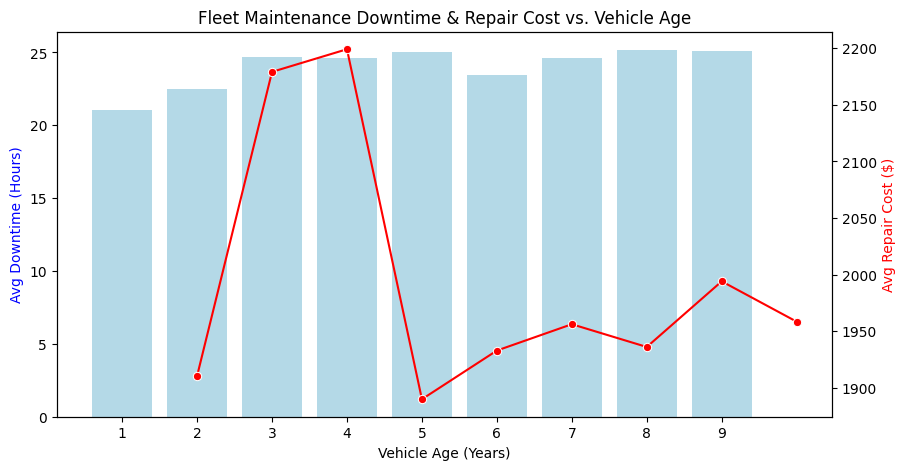

In [ ]:
query_maintenance = """
SELECT
    t.truck_id,
    t.model_year,
    CAST(strftime('%Y', m.maintenance_date) AS INT) - t.model_year AS vehicle_age_years,
    m.maintenance_type,
    m.downtime_hours,
    (m.labor_cost + m.parts_cost) AS total_repair_cost
FROM maintenance_records m
JOIN trucks t ON m.truck_id = t.truck_id;
"""

df_maint = pd.read_sql_query(query_maintenance, conn)

# Aggregate metrics by Vehicle Age
age_summary = df_maint.groupby('vehicle_age_years').agg(
    avg_downtime_hours=('downtime_hours', 'mean'),
    total_downtime_hours=('downtime_hours', 'sum'),
    avg_repair_cost=('total_repair_cost', 'mean'),
    incident_count=('downtime_hours', 'count')
).reset_index()

# Plot Downtime & Costs vs Vehicle Age
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=age_summary, x='vehicle_age_years', y='avg_downtime_hours', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_ylabel('Avg Downtime (Hours)', color='blue')
ax1.set_xlabel('Vehicle Age (Years)')

ax2 = ax1.twinx()
sns.lineplot(data=age_summary, x='vehicle_age_years', y='avg_repair_cost', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Avg Repair Cost ($)', color='red')
plt.title('Fleet Maintenance Downtime & Repair Cost vs. Vehicle Age')
plt.show()

**Tracking Cost-Per-Mile (CPM)**

In [ ]:
# Check column names for trips and other key tables
for table_name in ['trucks', 'maintenance_records', 'fuel_purchases', 'drivers', 'trips', 'loads', 'truck_utilization_metrics']:
    cols = [col[1] for col in conn.execute(f"PRAGMA table_info({table_name});").fetchall()]
    print(f"Table '{table_name}' columns:\n  {cols}\n")

Table 'trucks' columns:
  ['truck_id', 'unit_number', 'make', 'model_year', 'vin', 'acquisition_date', 'acquisition_mileage', 'fuel_type', 'tank_capacity_gallons', 'status', 'home_terminal']

Table 'maintenance_records' columns:
  ['maintenance_id', 'truck_id', 'maintenance_date', 'maintenance_type', 'odometer_reading', 'labor_hours', 'labor_cost', 'parts_cost', 'total_cost', 'facility_location', 'downtime_hours', 'service_description']

Table 'fuel_purchases' columns:
  ['fuel_purchase_id', 'trip_id', 'truck_id', 'driver_id', 'purchase_date', 'location_city', 'location_state', 'gallons', 'price_per_gallon', 'total_cost', 'fuel_card_number']

Table 'drivers' columns:
  ['driver_id', 'first_name', 'last_name', 'hire_date', 'termination_date', 'license_number', 'license_state', 'date_of_birth', 'home_terminal', 'employment_status', 'cdl_class', 'years_experience']

Table 'trips' columns:
  ['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id', 'dispatch_date', 'actual_distance_mil

In [ ]:
query_cpm = """
WITH truck_miles AS (
    SELECT truck_id, SUM(actual_distance_miles) AS total_miles
    FROM trips
    GROUP BY truck_id
),
fuel_costs AS (
    SELECT truck_id, SUM(total_cost) AS total_fuel_cost
    FROM fuel_purchases
    GROUP BY truck_id
),
maint_costs AS (
    SELECT truck_id, SUM(labor_cost + parts_cost) AS total_maint_cost
    FROM maintenance_records
    GROUP BY truck_id
)
SELECT
    tm.truck_id,
    tm.total_miles,
    COALESCE(fc.total_fuel_cost, 0) AS fuel_cost,
    COALESCE(mc.total_maint_cost, 0) AS maint_cost,
    (COALESCE(fc.total_fuel_cost, 0) + COALESCE(mc.total_maint_cost, 0)) / NULLIF(tm.total_miles, 0) AS cost_per_mile
FROM truck_miles tm
LEFT JOIN fuel_costs fc ON tm.truck_id = fc.truck_id
LEFT JOIN maint_costs mc ON tm.truck_id = mc.truck_id;
"""

df_cpm = pd.read_sql_query(query_cpm, conn)
df_cpm.head()

,truck_id,total_miles,fuel_cost,maint_cost,cost_per_mile
0,None,2423015,0.00,0.00,0.000000
1,TRK00001,1356397,1086194.17,51775.99,0.838965
2,TRK00002,1270572,995986.71,54869.04,0.827073
3,TRK00004,1309547,1034663.13,38561.82,0.819539
4,TRK00006,1278551,987959.30,50780.83,0.812435


Fleet Average Cost Per Mile: $0.81


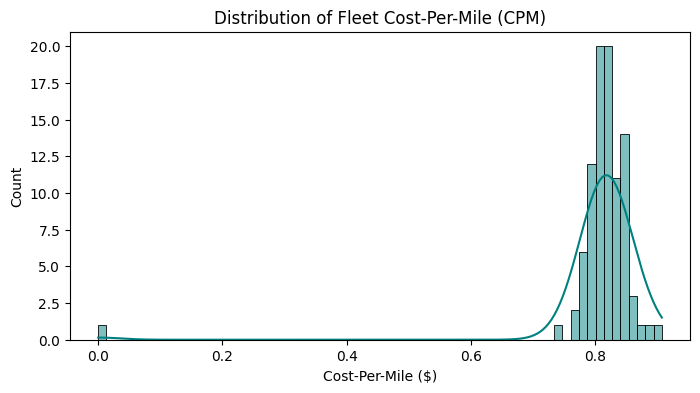

In [ ]:
query_cpm = """
WITH truck_miles AS (
    SELECT truck_id, SUM(actual_distance_miles) AS total_miles
    FROM trips
    GROUP BY truck_id
),
fuel_costs AS (
    SELECT truck_id, SUM(total_cost) AS total_fuel_cost
    FROM fuel_purchases
    GROUP BY truck_id
),
maint_costs AS (
    SELECT truck_id, SUM(labor_cost + parts_cost) AS total_maint_cost
    FROM maintenance_records
    GROUP BY truck_id
)
SELECT
    tm.truck_id,
    tm.total_miles,
    COALESCE(fc.total_fuel_cost, 0) AS fuel_cost,
    COALESCE(mc.total_maint_cost, 0) AS maint_cost,
    (COALESCE(fc.total_fuel_cost, 0) + COALESCE(mc.total_maint_cost, 0)) / NULLIF(tm.total_miles, 0) AS cost_per_mile
FROM truck_miles tm
LEFT JOIN fuel_costs fc ON tm.truck_id = fc.truck_id
LEFT JOIN maint_costs mc ON tm.truck_id = mc.truck_id;
"""

df_cpm = pd.read_sql_query(query_cpm, conn)

print(f"Fleet Average Cost Per Mile: ${df_cpm['cost_per_mile'].mean():.2f}")

# Distribution of CPM across vehicles
plt.figure(figsize=(8, 4))
sns.histplot(df_cpm['cost_per_mile'].dropna(), kde=True, color='teal')
plt.title('Distribution of Fleet Cost-Per-Mile (CPM)')
plt.xlabel('Cost-Per-Mile ($)')
plt.show()

**Modeling Driver Retention (Churn Risk)**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         4

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



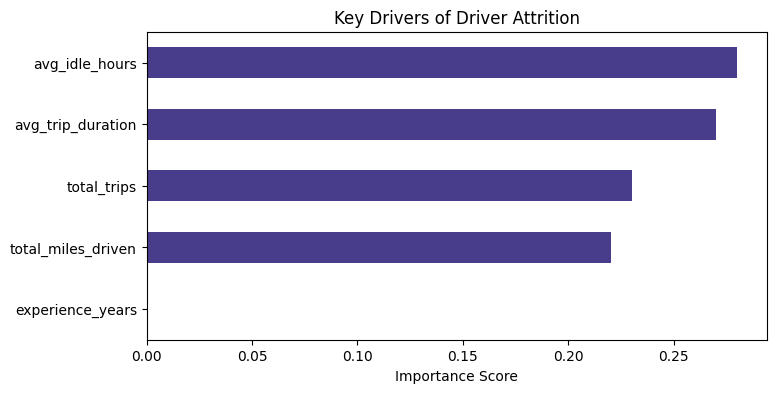

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Feature Extraction SQL
query_drivers_robust = """
SELECT
    d.driver_id,
    d.employment_status AS current_status,
    COALESCE(d.years_experience, 0) AS experience_years,
    COUNT(DISTINCT t.trip_id) AS total_trips,
    COALESCE(SUM(t.actual_distance_miles), 0) AS total_miles_driven,
    COALESCE(AVG(t.actual_duration_hours), 0) AS avg_trip_duration,
    COALESCE(AVG(t.idle_time_hours), 0) AS avg_idle_hours,
    COALESCE(SUM(l.weight_lbs), 0) AS total_weight_hauled
FROM drivers d
LEFT JOIN trips t ON d.driver_id = t.driver_id
LEFT JOIN loads l ON t.load_id = l.load_id
GROUP BY d.driver_id;
"""

df_drivers = pd.read_sql_query(query_drivers_robust, conn)


# Target Variable: 1 if Terminated/Inactive, 0 if Active
df_drivers['is_churned'] = df_drivers['current_status'].apply(lambda x: 1 if x in ['Terminated', 'Inactive'] else 0)

# Features & Target Selection
X = df_drivers[['experience_years', 'total_trips', 'total_miles_driven', 'avg_trip_duration', 'avg_idle_hours']]
y = df_drivers['is_churned']

# 2. Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 3. Evaluate & Feature Importance
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Plot Feature Importance
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='darkslateblue', figsize=(8, 4))
plt.title('Key Drivers of Driver Attrition')
plt.xlabel('Importance Score')
plt.show()